# Smoothness Metrics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any, Optional
import robomimic.dev.hparam.metric_fn as Metrics
import copy
from robomimic.dev.hparam.eval_suite import HparamAnalyzer
from matplotlib.collections import PolyCollection
import seaborn as sns
import pickle
import math
import robomimic.dev.hparam.utils.movements_utils as Movements

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from robomimic.dev.smoothness_metrics.smoothness_metrics import sparc, analyze_trajectory_smoothness
import pickle

# Load demo data
pkl_path = "path/to/your/demo.pkl" 
with open(pkl_path, "rb") as f:
    data = pickle.load(f)

# Analyze smoothness
success_vec, smoothness_scores, traj_indices = analyze_trajectory_smoothness(
    data, 
    metric_fn="sparc",
    dt=0.05,
    type="real"
)

# Plotting
plt.figure(figsize=(18, 6))

# Plot 1: Raw trajectories
plt.subplot(1, 3, 1)
for i, (score, success) in enumerate(zip(smoothness_scores, success_vec)):
    color = "green" if success else "red"
    alpha = 0.2 if success else 0.5
    linestyle = "-." if success else "-"
    plt.plot(traj_indices[i], score, color=color, alpha=alpha, linestyle=linestyle)
plt.grid(True)
plt.title("Raw Trajectories")

# Plot 2: Smoothness Distribution
plt.subplot(1, 3, 2) 
plt.hist(smoothness_scores[success_vec], alpha=0.5, color='green', label='Success')
plt.hist(smoothness_scores[~success_vec], alpha=0.5, color='red', label='Failure')
plt.legend()
plt.title("Smoothness Distribution")
plt.grid(True)

# Plot 3: Smoothness vs Success
plt.subplot(1, 3, 3)
plt.scatter(smoothness_scores, success_vec, alpha=0.5)
plt.xlabel("Smoothness Score")
plt.ylabel("Success")
plt.title("Smoothness vs Success")
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'Union' is not defined

### Discrete Fourier Transform

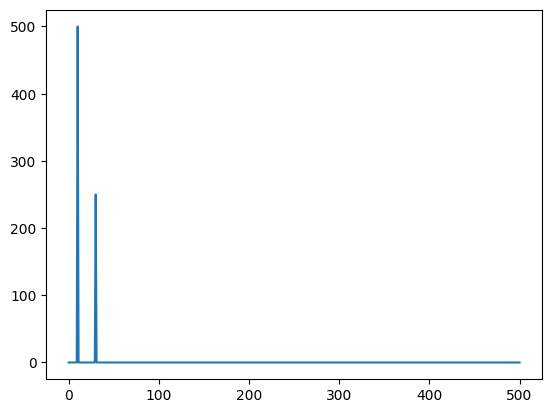

In [2]:
fs = 1000
dt = 1/fs
f_signal1 = 10
f_signal2 = 30
ts = np.arange(0, 1, dt)
ys_fast = np.cos(2*np.pi*f_signal1*ts)+ 0.5*np.sin(2*np.pi*f_signal2*ts)
ys_slow = np.cos(2*np.pi/4*f_signal1*ts)+ 0.5*np.sin(2*np.pi/4*f_signal2*ts)

Mf = np.abs(np.fft.rfft(ys_fast))
freq = np.fft.rfftfreq(ts.shape[0])*fs

plt.plot(freq, Mf)


### Developing SPARC: Smoothness Metric

In [3]:
def pos_to_speed(positions, dt):
    if len(positions) < 2:
        return 0.0
    vel = (positions[1:] - positions[:-1]) / dt
    speed = np.linalg.norm(vel, axis = 1)
    return speed

def sparc_official(movements, dt, padlevel=4, fc=20.0, amp_th=0.05, return_data=False):
    fs = int(1/dt)

    nfft = int(pow(2, np.ceil(np.log2(len(movements)))+padlevel))

    f  = np.fft.rfftfreq(nfft) * fs
    Mf = abs(np.fft.rfft(movements, nfft))
    Mf = Mf / Mf.max()

    # maximum frequency cut
    fc_inx = ((f <= fc) * 1).nonzero()
    f_sel  = f[fc_inx]
    Mf_sel = Mf[fc_inx]

    # minimum V0 cut
    inx = ((Mf_sel >= amp_th) * 1).nonzero()[0]
    fc_inx = range(inx[0], inx[-1] + 1)
    f_sel = f_sel[fc_inx]
    Mf_sel = Mf_sel[fc_inx]

    sparc = -np.sqrt(
        (np.diff(f_sel) / (f_sel[-1] - f_sel[0])) ** 2 + \
        (np.diff(Mf_sel))** 2
    ).sum()

    if return_data:
        return sparc, (f, Mf), (f_sel, Mf_sel)
    else:
        return sparc

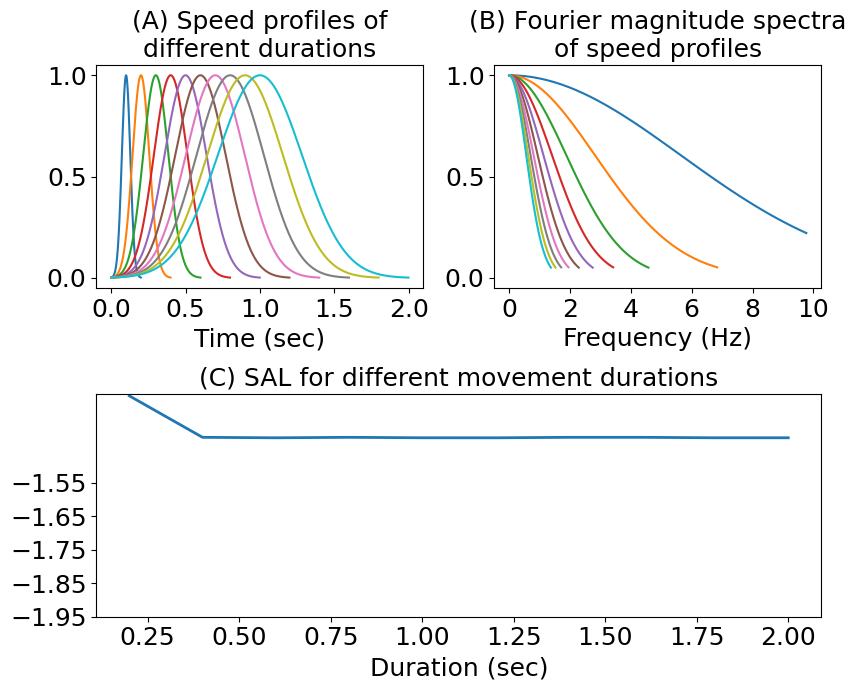

In [4]:
# Validation
# Guassian movement parameters.
ts = 0.001
amp = 1.0
dur = np.linspace(0.2, 2.0, num=10)
loc = dur / 2.0
times = [np.arange(0., _d, ts) for _d in dur]

# Index of movement with duration 1 sec
dur_inx = np.nonzero(dur == 1.0)[0][0]

# Gaussian movements
moves = [Movements.gaussian_discrete_movement(amp=amp, 
                     dur=dur[i],
                     loc=loc[i], 
                     time=times[i]) for i in range(len(dur))]


# Estimate smoothness using SAL.
sal = np.zeros(len(dur))
_spec = [0] * len(dur)

# The SPARC function is used to estimate smoothness. The SPARC is equal to the 
# SAL when the amp_th is set to zero, and fc is set to 20Hz.
for i in range(0, len(dur)):
    sal[i], _, _spec[i] = sparc_official(moves[i], dt=ts, padlevel=4, fc=10., amp_th=0.05, return_data=True)
    
# Plot data.
fig = plt.figure(figsize=(8.5,7))
# speed profile plot
plt.subplot2grid(shape=(2,2), loc=(0,0), rowspan=1, colspan=1)
for i in range(0, len(dur), 1):
    plt.plot(times[i], moves[i], lw=1.5)
plt.ylim(-0.05, 1.05)
plt.title('(A) Speed profiles of\ndifferent durations', fontsize=18)
plt.xlabel('Time (sec)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks([0., 0.5, 1.0], fontsize=18)

# Fourier spectrum plot.
plt.subplot2grid(shape=(2,2), loc=(0,1), rowspan=1, colspan=1)
for i in range(0, len(dur), 1):
    plt.plot(_spec[i][0], _spec[i][1], lw=1.5)
plt.ylim(-0.05, 1.05)
plt.title('(B) Fourier magnitude spectra\nof speed profiles', fontsize=18)
plt.xlabel('Frequency (Hz)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks([0., 0.5, 1.0], fontsize=18)

# Change of SAL with movement duration.
plt.subplot2grid(shape=(2,2), loc=(1,0), rowspan=1, colspan=2)
plt.plot(dur, sal, lw=2)  #plot(dur, sal - sal[dur_inx], lw=2)
plt.title('(C) SAL for different movement durations', fontsize=18)
plt.xlabel('Duration (sec)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(np.arange(-1.95, -1.5, 0.1), fontsize=18)

plt.tight_layout()

### Pickle Path

## SPARC based on Velocity

In [26]:
pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_inp_t_ts_40_eta_1_nres_1_iter_0_2025-01-08 14:01:21.391115.pkl"
pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_inp_t_ts_100_eta_1_nres_0_iter_2_2025-01-08 20:57:42.734537.pkl"
pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/baseline/square_image_action_horizon_16_inp_t_ts_0_eta_1_nres_0_iter_1_2025-01-09 13:49:13.399909.pkl"
with open(pkl_path, "rb") as f:
    data = pickle.load(f)

Succ 0
Succ 1
Fail 4
Fail 5
Succ 14
Succ 34
Fail 44
Fail 54
Fail 57
Fail 68


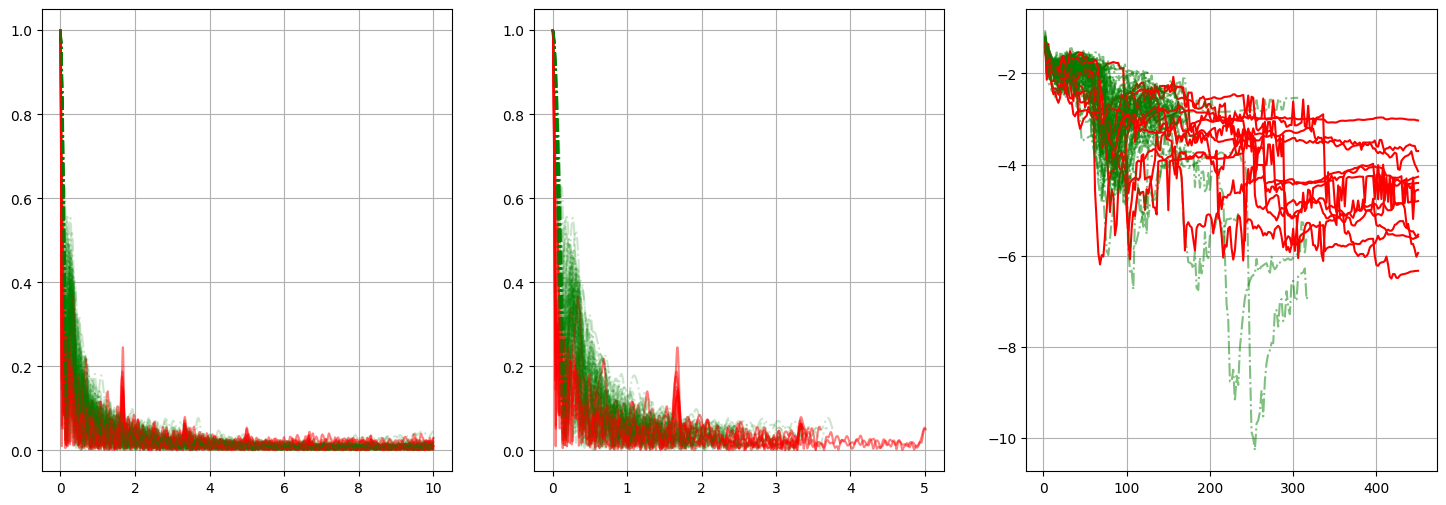

In [27]:
# SPARC hyperparameter
amp_th = 0.05

# No-filtered FFT result
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
success_vec = data["stats"]["Success_Rate"]
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_velocity(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']

    color = "green" if success_vec[i] else "red"
    alpha = 0.2 if success_vec[i] else 0.5
    linestyle = "-." if success_vec[i] else "-"
    sparc_i, fft_result, _ = sparc_official(speed_i, dt, return_data=True)

    freqs = fft_result[0]
    speed_fft = fft_result[1]

    plt.plot(freqs, speed_fft, color ,alpha=alpha, linestyle=linestyle)
    plt.grid(True)

plt.subplot(1, 3, 2)
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_velocity(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']

    color = "green" if success_vec[i] else "red"
    alpha = 0.2 if success_vec[i] else 0.5
    linestyle = "-." if success_vec[i] else "-"
    sparc_i, _, fft_result = sparc_official(speed_i, dt, return_data=True, amp_th=amp_th)

    freqs = fft_result[0]
    speed_fft = fft_result[1]

    plt.plot(freqs, speed_fft, color ,alpha=alpha, linestyle=linestyle)
    plt.grid(True)

N_skip = 2
success_vec = data["stats"]["Success_Rate"]
plt.subplot(1, 3, 3)
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_velocity(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']
    sparc_vec_i = []

    t_eval = np.arange(N_skip, speed_i.shape[0], N_skip)
    for j in t_eval:
        sparc_ij = sparc_official(speed_i[:j], dt, amp_th = amp_th, padlevel=4)
        sparc_vec_i.append(sparc_ij)
    
    if np.array(sparc_vec_i).min() < -6:
        if success_vec[i] > 0.5:
            print("Succ", i)
        else:
            print("Fail", i)
    color = "green" if success_vec[i] else "red"
    alpha = 0.5 if success_vec[i] else 1
    linestyle = "-." if success_vec[i] else "-"
    plt.plot(t_eval, sparc_vec_i, color, alpha=alpha, linestyle=linestyle)
    plt.grid(True)

## SPARC based on Twist

In [18]:
pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_inp_t_ts_40_eta_1_nres_1_iter_0_2025-01-08 14:01:21.391115.pkl"
# pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_inp_t_ts_100_eta_1_nres_0_iter_2_2025-01-08 20:57:42.734537.pkl"
with open(pkl_path, "rb") as f:
    data = pickle.load(f)

Fail 4
Succ 14
Fail 19
Fail 44
Fail 49
Fail 50
Fail 54
Fail 57


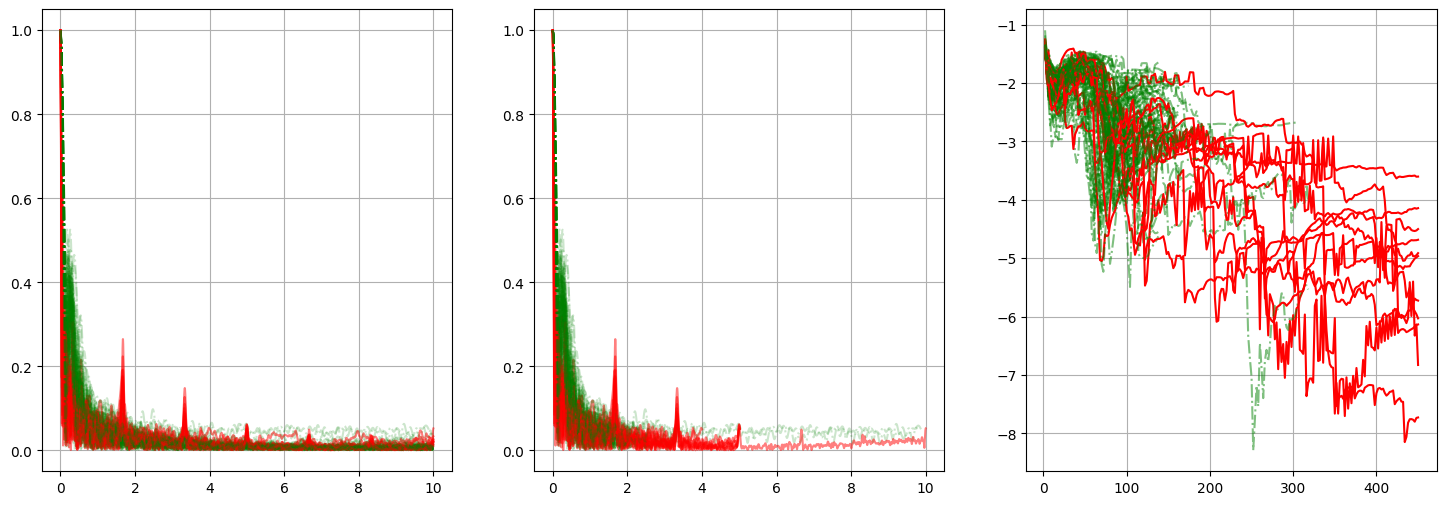

In [28]:
# SPARC hyperparameter
amp_th = 0.05

# No-filtered FFT result
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
success_vec = data["stats"]["Success_Rate"]
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_twist(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']

    color = "green" if success_vec[i] else "red"
    alpha = 0.2 if success_vec[i] else 0.5
    linestyle = "-." if success_vec[i] else "-"
    sparc_i, fft_result, _ = sparc_official(speed_i, dt, return_data=True)

    freqs = fft_result[0]
    speed_fft = fft_result[1]

    plt.plot(freqs, speed_fft, color ,alpha=alpha, linestyle=linestyle)
    plt.grid(True)

plt.subplot(1, 3, 2)
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_twist(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']

    color = "green" if success_vec[i] else "red"
    alpha = 0.2 if success_vec[i] else 0.5
    linestyle = "-." if success_vec[i] else "-"
    sparc_i, _, fft_result = sparc_official(speed_i, dt, return_data=True, amp_th=amp_th)

    freqs = fft_result[0]
    speed_fft = fft_result[1]

    plt.plot(freqs, speed_fft, color ,alpha=alpha, linestyle=linestyle)
    plt.grid(True)

N_skip = 2
success_vec = data["stats"]["Success_Rate"]
plt.subplot(1, 3, 3)
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_twist(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']
    sparc_vec_i = []

    t_eval = np.arange(N_skip, speed_i.shape[0], N_skip)
    for j in t_eval:
        sparc_ij = sparc_official(speed_i[:j], dt, amp_th = amp_th, padlevel=4)
        sparc_vec_i.append(sparc_ij)
    
    if np.array(sparc_vec_i).min() < -6:
        if success_vec[i] > 0.5:
            print("Succ", i)
        else:
            print("Fail", i)
    color = "green" if success_vec[i] else "red"
    alpha = 0.5 if success_vec[i] else 1
    linestyle = "-." if success_vec[i] else "-"
    plt.plot(t_eval, sparc_vec_i, color, alpha=alpha, linestyle=linestyle)
    plt.grid(True)

## SPARC based on Angular Velocity

In [30]:
pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_inp_t_ts_40_eta_1_nres_1_iter_0_2025-01-08 14:01:21.391115.pkl"
# pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_inp_t_ts_100_eta_1_nres_0_iter_2_2025-01-08 20:57:42.734537.pkl"
with open(pkl_path, "rb") as f:
    data = pickle.load(f)

Fail 4
Fail 5
Succ 14
Succ 15
Fail 19
Succ 24
Fail 44
Fail 49
Fail 50
Fail 54
Fail 57


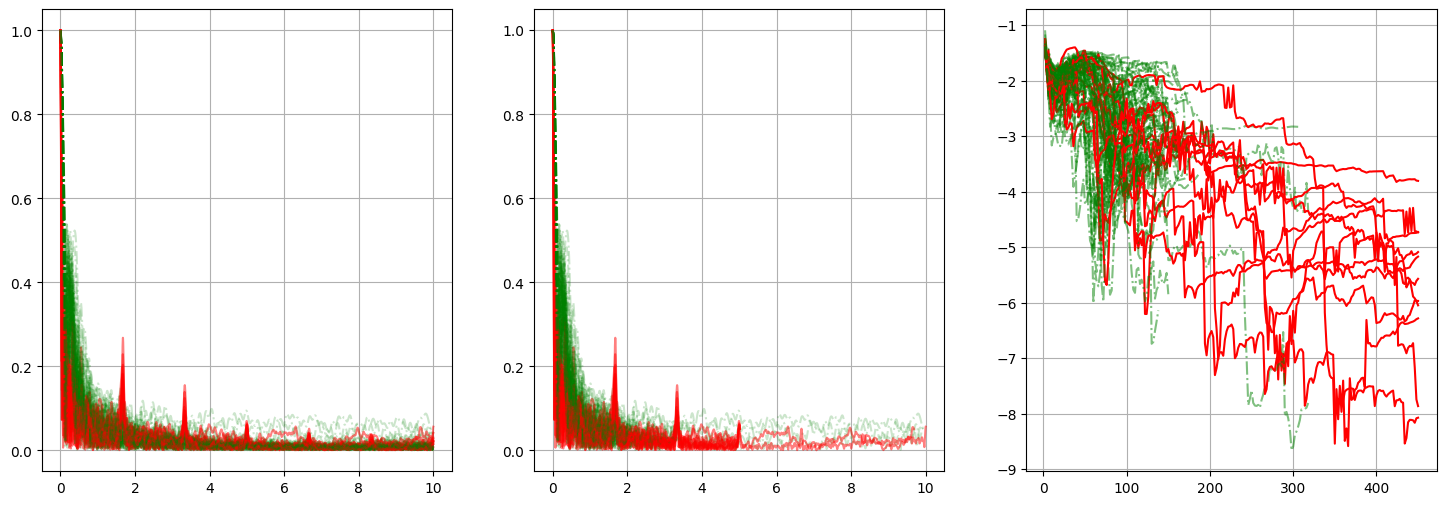

In [29]:
# SPARC hyperparameter
amp_th = 0.05

# No-filtered FFT result
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
success_vec = data["stats"]["Success_Rate"]
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_angular_velocity(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']

    color = "green" if success_vec[i] else "red"
    alpha = 0.2 if success_vec[i] else 0.5
    linestyle = "-." if success_vec[i] else "-"
    sparc_i, fft_result, _ = sparc_official(speed_i, dt, return_data=True)

    freqs = fft_result[0]
    speed_fft = fft_result[1]

    plt.plot(freqs, speed_fft, color ,alpha=alpha, linestyle=linestyle)
    plt.grid(True)

plt.subplot(1, 3, 2)
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_angular_velocity(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']

    color = "green" if success_vec[i] else "red"
    alpha = 0.2 if success_vec[i] else 0.5
    linestyle = "-." if success_vec[i] else "-"
    sparc_i, _, fft_result = sparc_official(speed_i, dt, return_data=True, amp_th=amp_th)

    freqs = fft_result[0]
    speed_fft = fft_result[1]

    plt.plot(freqs, speed_fft, color ,alpha=alpha, linestyle=linestyle)
    plt.grid(True)

N_skip = 2
success_vec = data["stats"]["Success_Rate"]
plt.subplot(1, 3, 3)
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_angular_velocity(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']
    sparc_vec_i = []

    t_eval = np.arange(N_skip, speed_i.shape[0], N_skip)
    for j in t_eval:
        sparc_ij = sparc_official(speed_i[:j], dt, amp_th = amp_th, padlevel=4)
        sparc_vec_i.append(sparc_ij)
    
    if np.array(sparc_vec_i).min() < -6:
        if success_vec[i] > 0.5:
            print("Succ", i)
        else:
            print("Fail", i)
    color = "green" if success_vec[i] else "red"
    alpha = 0.5 if success_vec[i] else 1
    linestyle = "-." if success_vec[i] else "-"
    plt.plot(t_eval, sparc_vec_i, color, alpha=alpha, linestyle=linestyle)
    plt.grid(True)

Fail 1
Succ 13
Fail 14
Succ 15
Fail 72
Succ 73


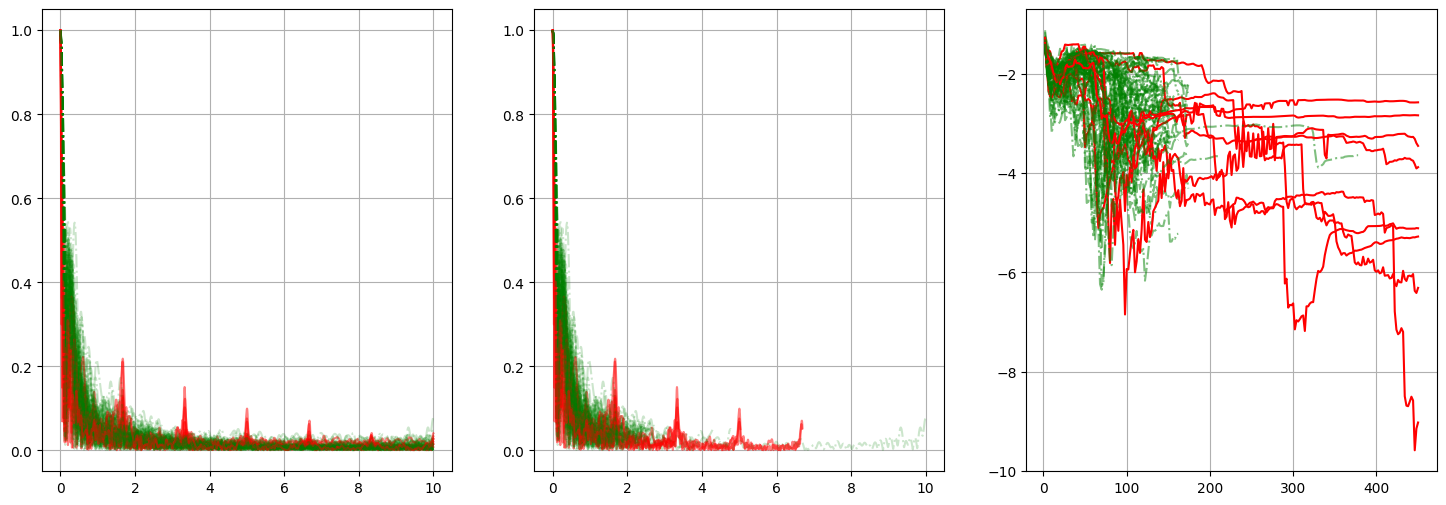

In [31]:
# SPARC hyperparameter
amp_th = 0.05

# No-filtered FFT result
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
success_vec = data["stats"]["Success_Rate"]
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_angular_velocity(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']

    color = "green" if success_vec[i] else "red"
    alpha = 0.2 if success_vec[i] else 0.5
    linestyle = "-." if success_vec[i] else "-"
    sparc_i, fft_result, _ = sparc_official(speed_i, dt, return_data=True)

    freqs = fft_result[0]
    speed_fft = fft_result[1]

    plt.plot(freqs, speed_fft, color ,alpha=alpha, linestyle=linestyle)
    plt.grid(True)

plt.subplot(1, 3, 2)
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_angular_velocity(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']

    color = "green" if success_vec[i] else "red"
    alpha = 0.2 if success_vec[i] else 0.5
    linestyle = "-." if success_vec[i] else "-"
    sparc_i, _, fft_result = sparc_official(speed_i, dt, return_data=True, amp_th=amp_th)

    freqs = fft_result[0]
    speed_fft = fft_result[1]

    plt.plot(freqs, speed_fft, color ,alpha=alpha, linestyle=linestyle)
    plt.grid(True)

N_skip = 2
success_vec = data["stats"]["Success_Rate"]
plt.subplot(1, 3, 3)
for i, demo in enumerate(data["rollouts"].values()):
    speed_i = Metrics.get_end_effector_angular_velocity(demo, type="real")
    speed_i = np.linalg.norm(speed_i, axis=-1)
    dt = 1/demo['kwargs']['fast_control_freq']
    sparc_vec_i = []

    t_eval = np.arange(N_skip, speed_i.shape[0], N_skip)
    for j in t_eval:
        sparc_ij = sparc_official(speed_i[:j], dt, amp_th = amp_th, padlevel=4)
        sparc_vec_i.append(sparc_ij)
    
    if np.array(sparc_vec_i).min() < -6:
        if success_vec[i] > 0.5:
            print("Succ", i)
        else:
            print("Fail", i)
    color = "green" if success_vec[i] else "red"
    alpha = 0.5 if success_vec[i] else 1
    linestyle = "-." if success_vec[i] else "-"
    plt.plot(t_eval, sparc_vec_i, color, alpha=alpha, linestyle=linestyle)
    plt.grid(True)

### Do similar analysis on knot: we are interested in which part we want to focus on